# Region embeddings from seqlet annotations

Seqlet-level information aggregated back to the regions the seqlets came from.

Needs a clustered seqlet AnnData from the previous tutorials, with:

- `obsm["X_pca"]` (written by {func}`~tfmindi.tl.embed_and_cluster`) for the default `"pca"` embedding
- `obs["attribution"]` for the attribution-weighted embedding (default, recommended)
- an annotation column in `.obs` for count-vector embeddings and region profiles
- a column grouping regions, e.g. `obs["cell_type"]`, to find an optimal clustering

```{note}
The outputs below come from a PBMC dataset rather than the brain data used in tutorials 01-02.
```

In [ ]:
import tfmindi as tm

/lustre1/project/stg_00002/mambaforge/vsc35840/envs/MINDI_DEV/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
seqlet_adata = tm.load_h5ad("tutorial_data/seqlets_clustered.h5ad")

The attribution, cell type and annotation columns:

In [ ]:
seqlet_adata.obs[["attribution", "cell_type", "predicted_5.0_predicted_family_no_cl"]].head()

,attribution,cell_type,predicted_5.0_predicted_family_no_cl
0,1.200954,Cytotoxic_T_cell,Runt
1,2.519469,Cytotoxic_T_cell,zf-C2H2
2,1.610592,Cytotoxic_T_cell,Runt
3,2.066564,Cytotoxic_T_cell,CP2
4,1.751482,Cytotoxic_T_cell,T-box


## Region embeddings from the seqlet PCA

{func}`~tfmindi.tl.embed_regions` averages each region's seqlet PCA coordinates, weighted by
attribution, and computes a t-SNE on the result.

In [ ]:
region_adata = tm.tl.embed_regions(seqlet_adata)

 [embed] Calculating weights
 [embed] Calculating pca embeddings on obsm.X_pca
 [embed] Calculating TSNE reduction...


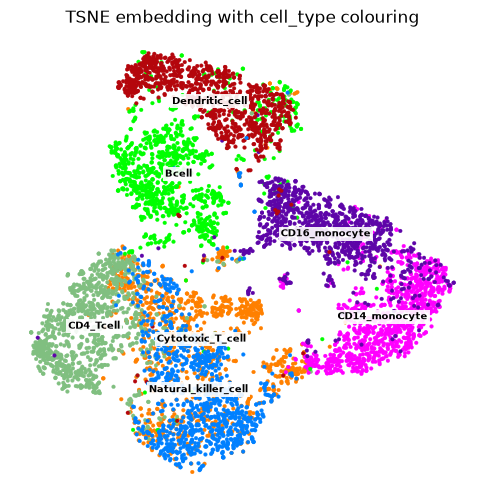

In [ ]:
palette = tm.pl.region_tsne(region_adata)

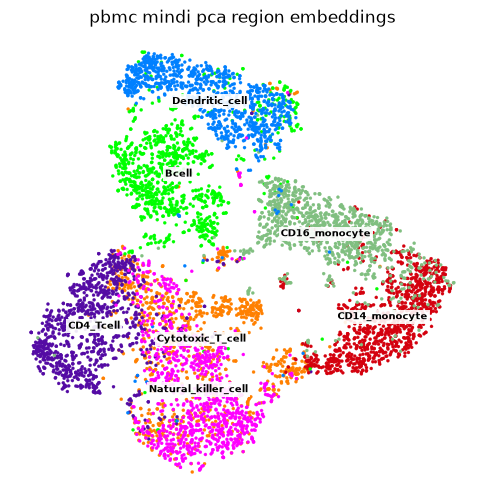

In [ ]:
_ = tm.pl.region_tsne(
    region_adata,
    obsm_key="TSNE",
    color_by="cell_type",
    title="pbmc mindi pca region embeddings",
    plot_legend=False,
    plot_labels=True,
    palette=palette,
    fig_edge=6,
    dot_size=5,
    clean=True,
)

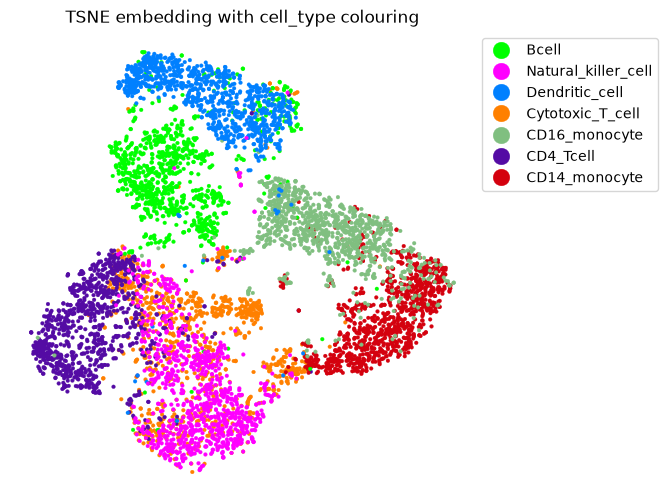

In [ ]:
_ = tm.pl.region_tsne(region_adata, plot_legend=True, plot_labels=False, palette=palette)

## Count vector embeddings

Instead of averaging coordinates, count how often each annotation occurs per region.

In [ ]:
region_adata_count = tm.tl.embed_regions(
    seqlet_adata,
    embedding="count",
    secondary="predicted_5.0_predicted_family",
    normalised=False,
)

 [embed] Calculating weights
 [embed] Calculating count embeddings by constructing count vectors at adata.obs['predicted_5.0_predicted_family'] resolution
 [embed] Calculating TSNE reduction...


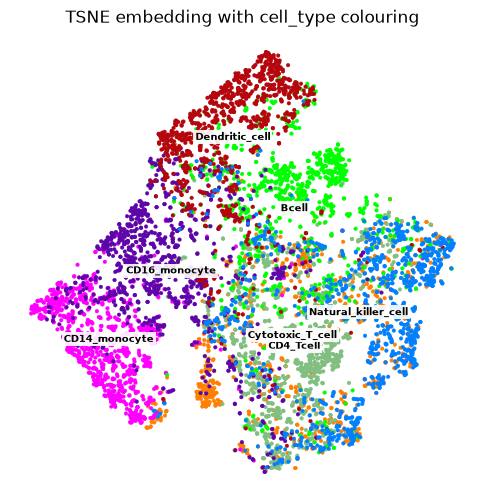

In [ ]:
_ = tm.pl.region_tsne(region_adata_count, palette=palette)

## Finding the best clustering of the embeddings

{func}`~tfmindi.tl.optimal_hierarchical_clustering` sweeps cut heights and keeps the one whose
clusters best agree with an existing region label (here `cell_type`).

 [clustering] Seeding embedding space with leiden clusters...
 [clustering] Build hierarchical tree...
 [clustering] Cutting at height 0.99
 [clustering] The optimal resolution is 0.44 with an ARI of 0.4406877298115642
 [clustering] Saved clusters in .obs region_cluster
 [clustering] Plotting...


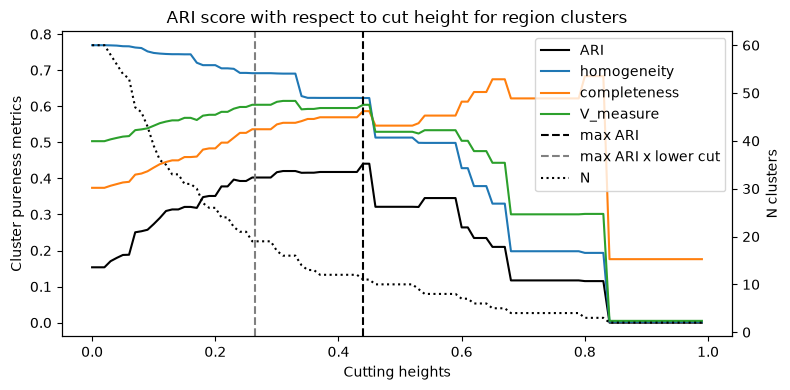

In [ ]:
tm.tl.optimal_hierarchical_clustering(region_adata, lower_cut=0.6)

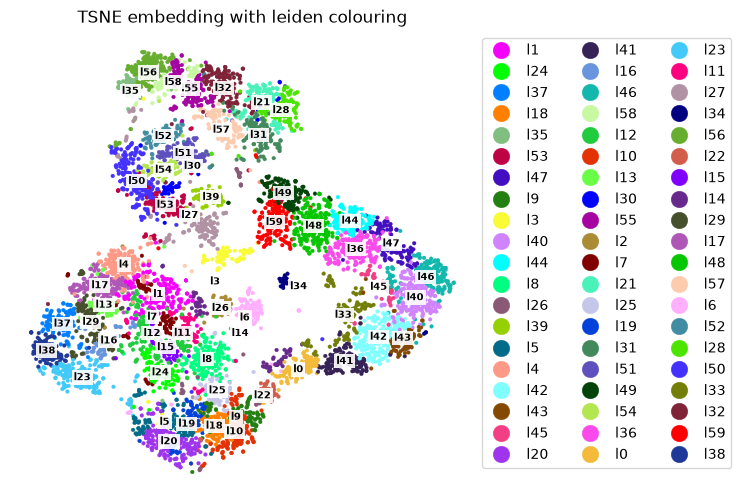

In [ ]:
_ = tm.pl.region_tsne(region_adata, color_by="leiden", plot_legend=True, plot_labels=True)

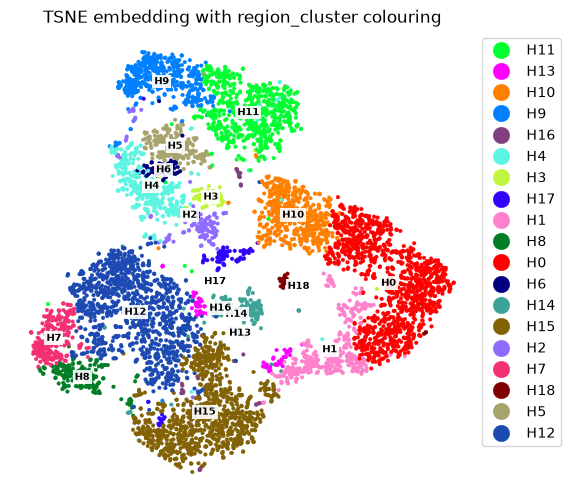

In [ ]:
_ = tm.pl.region_tsne(region_adata, color_by="region_cluster", plot_legend=True, plot_labels=True)

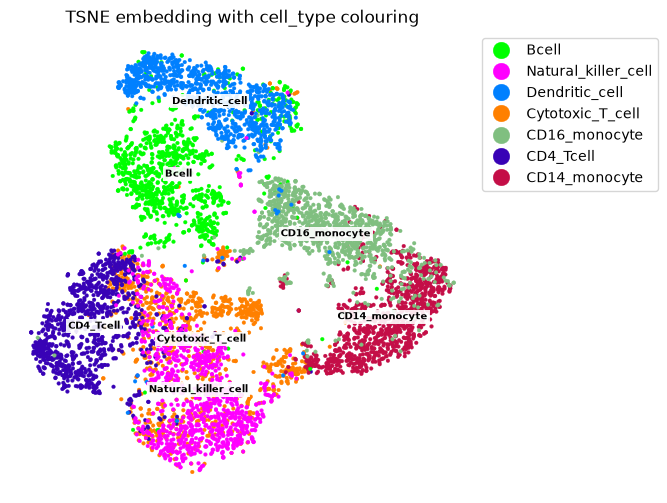

In [ ]:
_ = tm.pl.region_tsne(region_adata, plot_legend=True, plot_labels=True)

## Region cluster profiles

Which motifs drive each region cluster.

In [ ]:
profiles = tm.tl.get_region_profiles(
    seqlet_adata,
    region_adata,
    annotation_col="predicted_5.0_predicted_family_no_cl",
    region_cluster_col="region_cluster",
)

/lustre1/project/stg_00002/mambaforge/vsc35840/envs/MINDI_DEV/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


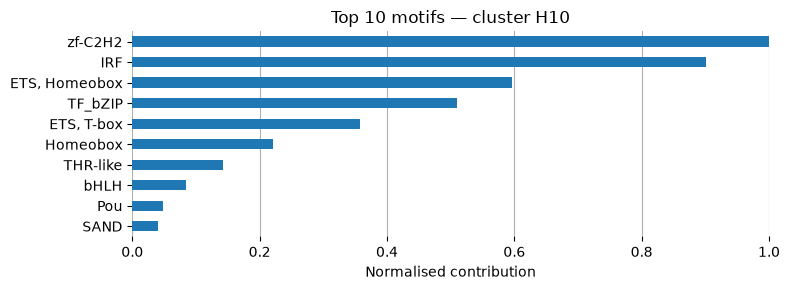

In [ ]:
tm.pl.plot_top_motifs(profiles, region_cluster="H10")

## Save the region object

In [ ]:
tm.save_h5ad(region_adata, "tutorial_data/regions.h5ad")